In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import numpy as np
from pathlib import Path

# Path.cwd() gets the current working directory (where your notebook lives)
# .parents[1] moves up two directories (equivalent to '../../')
project_root = Path.cwd().parents[1]

sys.path.insert(0, str(project_root.resolve()))
from src.simulations.GBM import (
    estimate_parameters,
    simulate_paths,
    simulate_paths2,
    simulate_correlated_GBM,
    estimate_Correlation_matrix
)
from src.data.statistics import compute_log_returns
from src.risk.var import loss_distribution

# Assuming returns is your log-return dataframe
AAPL=pd.read_parquet(r"D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\data\raw\AAPL.parquet")
NVDA=pd.read_parquet(r"D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\data\raw\NVDA.parquet")
JPM=pd.read_parquet(r"D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\data\raw\JPM.parquet")
SPY=pd.read_parquet(r"D:\Documentos\Vida_profesional\Coding\Projects\Quant_Risk_Engine\src\data\raw\SPY.parquet")
prices = pd.DataFrame({
    "AAPL": AAPL["adj_close"],
    "NVDA":NVDA['adj_close'],
    "JPM":JPM["adj_close"],
    "SPY":SPY['adj_close']
})
returns = compute_log_returns(prices)

In [12]:
prices=prices.dropna()

In [13]:
corraleted_matrix=estimate_Correlation_matrix(returns)
n_paths=5000
n_assets=4
years=3
steps_per_year=252
paths=simulate_correlated_GBM(
    corr_matrix=corraleted_matrix,
    prices=prices,
    returns=returns,
    n_paths=n_paths,
    n_assets=n_assets,
    years=years,
    steps_per_year=steps_per_year,
)

S0:[308.32998657 214.60987854 306.73999023 750.59002686]


Theoretical mean: [0.22750262 0.56223202 0.14932896 0.14553615], Theoretical sigma: [0.31314999 0.52045169 0.30932244 0.20422683]


In [50]:
historical_return = prices.iloc[-1] / prices.iloc[0] - 1
simulated_returns = paths[-1]/paths[0] - 1
print(historical_return)
for i in range(4):
    print(np.mean(simulated_returns[i,:]))

AAPL     3.262594
NVDA    34.985411
JPM      1.590046
SPY      1.528191
dtype: float64
0.9847900384734461
4.477953483111247
0.5840211430854529
0.552847737386277


In [64]:
paths.shape

(756, 4, 5000)

In [67]:
mu = (returns.mean() * 252).to_numpy()
sigma = (returns.std() * np.sqrt(252)).to_numpy()
print(f"Theoretical mean: {mu}, Theoretical sigma: {sigma}")
simulated_mu = np.mean(simulated_returns[:4, :], axis=1)
simulated_sigma = np.std(simulated_returns[:4, :], axis=1)

Theoretical mean: [0.22750262 0.56223202 0.14932896 0.14553615], Theoretical sigma: [0.31314999 0.52045169 0.30932244 0.20422683]


In [75]:
T = 756 / 252

theoretical_mean = (mu - 0.5*sigma**2) * T
theoretical_std  = sigma * np.sqrt(T)

print(theoretical_mean)
print(theoretical_std)


[0.53541348 1.28039113 0.30446631 0.37404556]
[0.5423917  0.90144876 0.53576218 0.35373125]


In [76]:
terminal_log_returns = np.log(paths[-1] / paths[0])

sim_mean = np.mean(terminal_log_returns, axis=1)
sim_std  = np.std(terminal_log_returns, axis=1)

print(sim_mean)
print(sim_std)

[0.53596611 1.27474153 0.31765014 0.37488681]
[0.54675674 0.9185022  0.53161342 0.36000973]


In [77]:
print(mu)
print(sigma)


[0.22750262 0.56223202 0.14932896 0.14553615]
[0.31314999 0.52045169 0.30932244 0.20422683]


In [39]:
returns_hist=returns.to_numpy()
#returns_hist=np.transpose(returns_hist)
print(returns_hist.shape)
losses_historical=loss_distribution(paths=returns_hist)
print(losses_historical.shape)

print(losses_historical)

(1606, 4)
0
0
(4,)
[-0.0081819  -0.01395024 -0.01445837 -0.01421731]


In [78]:
losses=paths[0]-paths[-1]

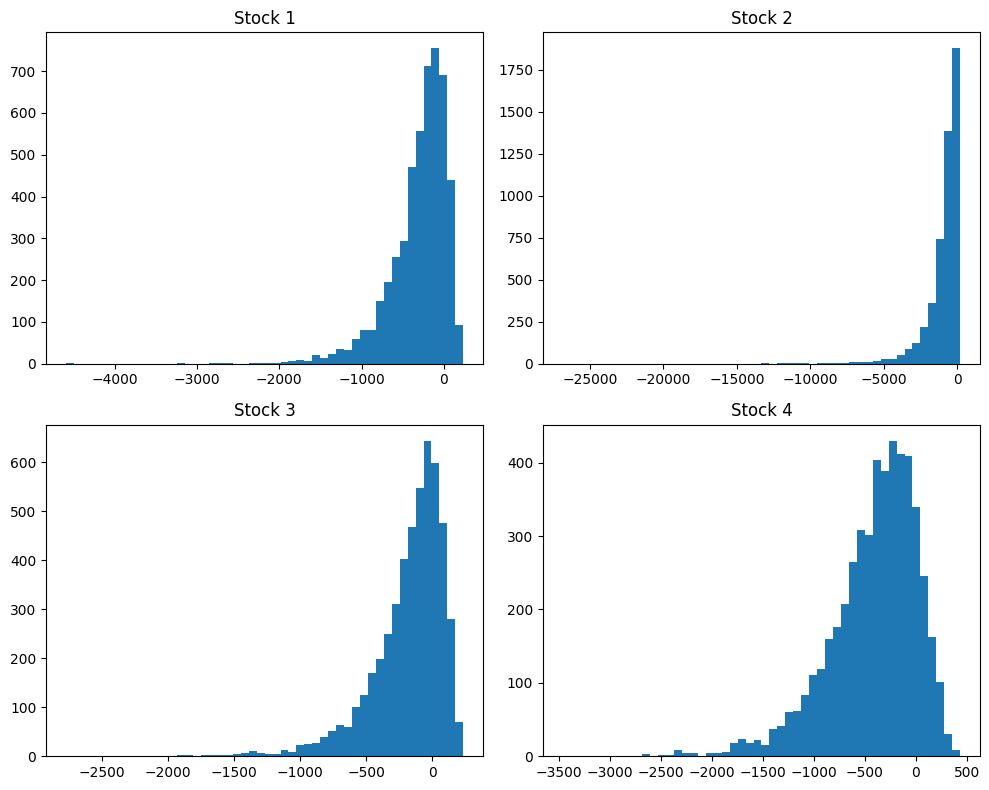

In [79]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flatten()):
    ax.hist(losses[i], bins=50)
    ax.set_title(f"Stock {i+1}")

plt.tight_layout()
plt.show()

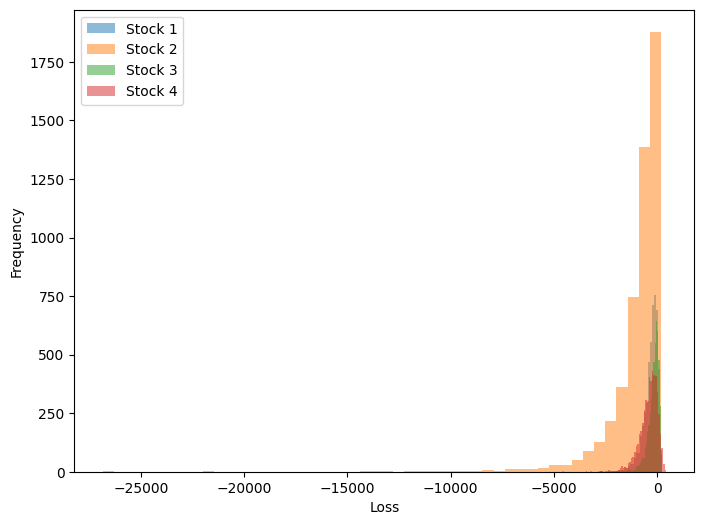

In [80]:
plt.figure(figsize=(8,6))

for i in range(4):
    plt.hist(losses[i], bins=50, alpha=0.5, label=f"Stock {i+1}")

plt.legend()
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.show()

In [83]:
var95 = np.percentile(losses, 95,axis=1)
var95

array([ 91.65907594,  44.56024086, 133.18812666, 142.01179521])

In [89]:
# var95 shape: (n_rows,), losses shape: (n_rows, n_sims)
mask = losses >= var95[:, None]               # broadcast column-wise
cvar95 = np.where(mask, losses, np.nan)
cvar95 = np.nanmean(cvar95, axis=1)    # Mean of tail losses per row
cvar95

array([133.58008002,  92.39212754, 162.22098514, 222.89338079])

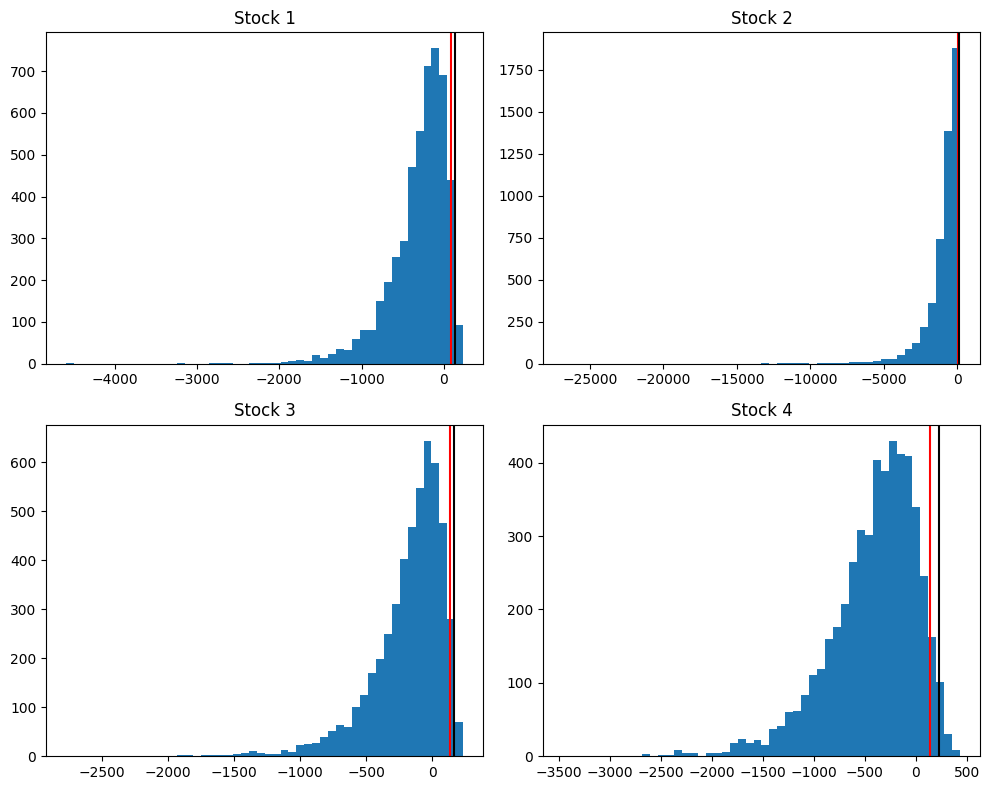

In [91]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flatten()):
    ax.hist(losses[i], bins=50)
    ax.set_title(f"Stock {i+1}")
    ax.axvline(var95[i], color="red")
    ax.axvline(cvar95[i], color="black")

plt.tight_layout()
plt.show()

In [95]:
weights = np.array([0.4, 0.3, 0.2, 0.1])

portfolio_paths = np.sum(
    paths * weights[None, :, None],
    axis=1
)
portfolio_losses = (
    portfolio_paths[0]
    - portfolio_paths[-1]
)
portolio_var95=np.percentile(portfolio_losses,95)
print(portolio_var95)
tail=losses[losses>=portolio_var95]

portfolio_cvar95=tail.mean()
print(portfolio_cvar95)

36.55655144451933
107.68750667995178


With the weights=np.array([0.4, 0.3, 0.2, 0.1]) we get a 
$$
VaR=36.55
$$
and 
$$
CVar=107.68
$$

Now what we must do is validate tha Monte Carlo Convergence. We will simulate the paths again from N=500, to N=100,000 and see how is the $VaR$ and $CVaR$ converge to some value

In [102]:
def get_var_and_cvar(n:int)->np.ndarray:
    corraleted_matrix=estimate_Correlation_matrix(returns)
    n_paths=n
    n_assets=4
    years=3
    steps_per_year=252
    paths=simulate_correlated_GBM(
    corr_matrix=corraleted_matrix,
    prices=prices,
    returns=returns,
    n_paths=n,
    n_assets=n_assets,
    years=years,
    steps_per_year=steps_per_year,
        )
    weights = np.array([0.4, 0.3, 0.2, 0.1])

    portfolio_paths = np.sum(
    paths * weights[None, :, None],
    axis=1
    )
    portfolio_losses = (
    portfolio_paths[0]
    - portfolio_paths[-1]
    )
    portolio_var95=np.percentile(portfolio_losses,95)
    tail=losses[losses>=portolio_var95]

    portfolio_cvar95=tail.mean()
    return portolio_var95,portfolio_cvar95




In [106]:
n=np.linspace(1000,1000000,10)
VaR=[]
CVaR=[]
for i in n:
    Var95,CvaR95=get_var_and_cvar(int(i))
    VaR.append(Var95)
    CVaR.append(CvaR95)



S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]
S0:[308.32998657 214.60987854 306.73999023 750.59002686]


MemoryError: Unable to allocate 15.0 GiB for an array with shape (756, 4, 667000) and data type float64

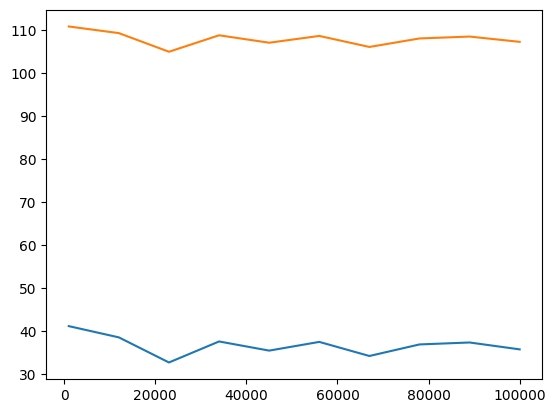

In [105]:
plt.plot(n,np.array(VaR))
plt.plot(n,np.array(CVaR))
plt.show()